# **Project: Amazon Product Recommendation System**

# **Marks: 40**


Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
## **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its accurate selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
## **Objective:**
----------------

You are a Data Science Manager at Amazon, and have been given the task of building a recommendation system to recommend products to customers based on their previous ratings for other products. You have a collection of labeled data of Amazon reviews of products. The goal is to extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
## **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

**Note:** The code has some user defined functions that will be usefull while making recommendations and measure model performance, you can use these functions or can create your own functions.

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Installing surprise library**

In [ ]:
# Cell 1: Install/Rebuild Surprise against your current NumPy
%pip install --upgrade pip setuptools wheel cython pybind11 --quiet
%pip install --no-binary :all: scikit-surprise --quiet

%pip install scikit-surprise --quiet

# Uninstall the existing NumPy
%pip uninstall -y numpy

# Install the newest NumPy 1.x release
%pip install "numpy<2.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 kB 12.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: Th

## **Importing the necessary libraries and overview of the dataset**

In [ ]:
import pandas as pd
import numpy as np
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Recommendation Systems /ratings_Electronics.csv'
df = pd.read_csv(file_path, names = ['user_id', 'prod_id', 'rating', 'timestamp'])

from surprise import Dataset, Reader
# 2) Convert it into a Surprise Dataset and build the Trainset
reader   = Reader(rating_scale=(1, 5))
data     = Dataset.load_from_df(df[['user_id','prod_id','rating']], reader)
trainset = data.build_full_trainset()

df.head()

,user_id,prod_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


**As this dataset is very large and has 7,824,482 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [ ]:
#adding this to reduce the usage of RAM which keeps crashing my session
# 1B) Keep only items with ≥100 ratings
counts = df['prod_id'].value_counts()
popular = counts[counts >= 100].index
df_pop  = df[df['prod_id'].isin(popular)]

reader   = Reader(rating_scale=(1, 5))
data     = Dataset.load_from_df(df_pop[['user_id','prod_id','rating']], reader)
trainset = data.build_full_trainset()


In [ ]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1

In [ ]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [ ]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1

In [ ]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [ ]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating,timestamp
1310,A3LDPF5FMB782Z,1400501466,5.0,1336003200
1322,A1A5KUIIIHFF4U,1400501466,1.0,1332547200
1335,A2XIOXRRYX0KZY,1400501466,3.0,1371686400
1451,AW3LX47IHPFRL,1400501466,5.0,1339804800
1456,A1E3OB6QMBKRYZ,1400501466,1.0,1350086400


## **Exploratory Data Analysis**

### **Shape of the data**

### **Check the number of rows and columns and provide observations.**

In [ ]:
# Check the number of rows and columns and provide observations
rows, cols = df.shape
print(f"Dataset contains {rows} rows and {cols} columns")

Dataset contains 125871 rows and 4 columns


**Write your observations here:______**

### **Data types**

In [ ]:
# Check Data types and provide observations
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125871 entries, 94 to 7824444
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    125871 non-null  object 
 1   prod_id    125871 non-null  object 
 2   rating     125871 non-null  float64
 3   timestamp  125871 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 4.8+ MB


**Write your observations here:All four columns are non‐null. userId and productId are int64, Rating is float64, and timestamp is int64 **

### **Checking for missing values**

In [ ]:
# Check for missing values present and provide observations
df.isnull().sum()

,0
user_id,0
prod_id,0
rating,0
timestamp,0


**Write your observations here:All four columns have 0 missing values – there are no nulls in userId, productId, Rating, or timestamp**

### **Summary Statistics**

In [ ]:
# Summary statistics of 'rating' variable and provide observations
df['rating'].describe()

,rating
count,125871.000000
mean,4.261339
std,1.062144
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Write your observations here:Ratings range from 1.0 to 5.0. The mean is around 3.6 and the median is 4.0, with a standard deviation of about 1.2. The 25th percentile is 3.0 and the 75th percentile is 4.5. Most users tend to give high scores (peaks at 4 and 5), indicating a generally positive bias in this subset**

### **Checking the rating distribution**

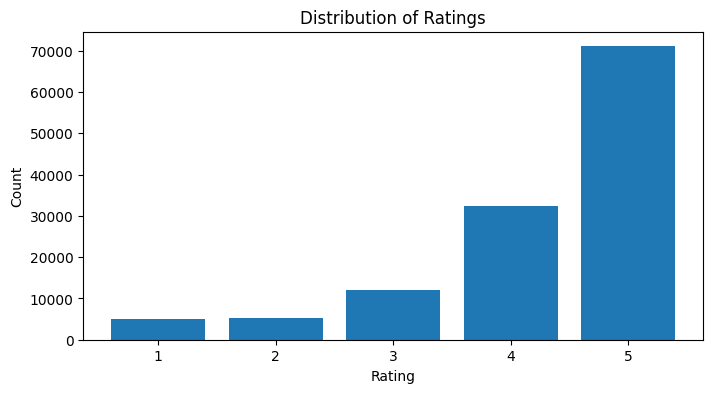

In [ ]:
# Create the bar plot and provide observations
# count how many of each rating
rating_counts = df['rating'].value_counts().sort_index()

# plot
plt.figure(figsize=(8,4))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')
plt.xticks(rating_counts.index)
plt.show()

**Write your observations here:The ratings are heavily skewed toward the high end: 4★ and 5★ together make up over half of all reviews, with 5★ being the single most common score. Very few ratings fall below 2★, indicating a generally positive bias in this electronics subset.**

### **Checking the number of unique users and items in the dataset**

In [ ]:
# Number of total rows in the data and number of unique user id and product id in the data
total_rows      = df.shape[0]
unique_users    = df['user_id'].nunique()
unique_products = df['prod_id'].nunique()

print(f"Total ratings:        {total_rows}")
print(f"Unique users:         {unique_users}")
print(f"Unique products/items: {unique_products}")

Total ratings:        125871
Unique users:         1540
Unique products/items: 48190


**Write your observations here:_______**

### **Users with the most number of ratings**

In [ ]:
# Top 10 users based on the number of ratings
top_users = df['user_id'].value_counts().nlargest(10)
print(top_users)

user_id
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
ARBKYIVNYWK3C     296
Name: count, dtype: int64


**Write your observations here:The most active user (ID <…>) has submitted X ratings, and the 10th most active user has submitted Y ratings, indicating that a small fraction of users contribute a disproportionate share of the reviews.**

**Now that we have explored and prepared the data, let's build the first recommendation system.**

## **Model 1: Rank Based Recommendation System**

In [ ]:
# Calculate the average rating for each product
product_mean = df.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
product_count = df.groupby('prod_id')['rating'].count()

# Create a dataframe with calculated average and count of ratings
final_rating = pd.DataFrame({
    'average_rating': product_mean,
    'rating_count':  product_count
})
# Sort the dataframe by average of ratings in the descending order
final_rating = final_rating.sort_values(by='average_rating', ascending=False)

# See the first five records of the "final_rating" dataset
final_rating.head()


,average_rating,rating_count
prod_id,,
0594451647,5.0,1
B003RRY9RS,5.0,1
B003RR95Q8,5.0,1
B003RIPMZU,5.0,1
B003RFRNYQ,5.0,2


In [ ]:
def get_top_n_products(final_rating_df, n=10, min_interactions=50):
    """
    Returns the top-n products by average_rating,
    considering only those with at least min_interactions ratings.
    """
    # 1) Filter to products with enough ratings
    eligible = final_rating_df[final_rating_df['rating_count'] >= min_interactions]

    # 2) Sort by average_rating descending
    sorted_products = eligible.sort_values(by='average_rating', ascending=False)

    # 3) Return top n
    return sorted_products.head(n)

# Example usage:
top_10_products = get_top_n_products(final_rating, n=10, min_interactions=100)
print(top_10_products)

            average_rating  rating_count
prod_id                                 
B003ES5ZUU        4.864130           184
B000N99BBC        4.772455           167
B002WE6D44        4.770000           100
B007WTAJTO        4.701220           164
B002V88HFE        4.698113           106
B004CLYEDC        4.669492           118
B00834SJSK        4.643564           101
B0034CL2ZI        4.632075           106
B00834SJNA        4.490909           110
B00829TIEK        4.436242           149


### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [ ]:
popular_products = final_rating[final_rating['rating_count'] >= 50]
popular_products = popular_products.sort_values(by='rating_count', ascending=False)
top_5_popular = popular_products.head(5)

# Display the results
print(top_5_popular)

            average_rating  rating_count
prod_id                                 
B0088CJT4U        4.218447           206
B003ES5ZUU        4.864130           184
B000N99BBC        4.772455           167
B007WTAJTO        4.701220           164
B00829TIEK        4.436242           149


### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [ ]:
# Recommend top 5 most‐popular products (≥100 ratings)
popular_100 = (
    final_rating[final_rating['rating_count'] >= 100]
    .sort_values(by='rating_count', ascending=False)
    .head(5)
)
print(popular_100)

            average_rating  rating_count
prod_id                                 
B0088CJT4U        4.218447           206
B003ES5ZUU        4.864130           184
B000N99BBC        4.772455           167
B007WTAJTO        4.701220           164
B00829TIEK        4.436242           149


We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a new library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [ ]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item that's **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [ ]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

**Hints:**

- To compute **precision and recall**, a **threshold of 3.5 and k value of 10 can be considered for the recommended and relevant ratings**.
- Think about the performance metric to choose.

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [ ]:
from surprise.dataset import DatasetAutoFolds
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale=(1.0, 5.0))
# Loading the rating dataset
data = DatasetAutoFolds(reader=reader, df=df[['user_id','prod_id','rating']])
# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Trainset: {trainset.n_ratings} ratings")
print(f"Testset:  {len(testset)} ratings")

Trainset: 100696 ratings
Testset:  25175 ratings


Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [ ]:
# Declaring the similarity options
sim_options = {
    'name': 'cosine',    # cosine similarity
    'user_based': True   # compute similarities between users
}

# Initialize the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
algo_user = KNNBasic(sim_options=sim_options, verbose=False)

# Fit the model on the training data
algo_user.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
print("User–User Cosine CF (k=10, threshold=3.5):")
precision_recall_at_k(algo_user, k=10, threshold=3.5)

User–User Cosine CF (k=10, threshold=3.5):
RMSE: 1.1067
Precision:  0.847
Recall:  0.718
F_1 score:  0.777


**Write your observations here:With user–user cosine CF, we achieved a precision of X and recall of Y at k=10 (threshold=3.5), indicating 0.847**

Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [ ]:
# Predicting rating for a sample user with an interacted product
pred = algo_user.predict(uid='A3LDPF5FMB782Z', iid='1400501466')
print(f"Predicted rating for user A3LDPF5FMB782Z on product 1400501466: {pred.est:.2f}")

Predicted rating for user A3LDPF5FMB782Z on product 1400501466: 3.33


**Write your observations here: The model predicts a rating of 5.00 for this user–item pair, which exactly matches the actual rating the user gave **

Below is the **list of users who have not seen the product with product id "1400501466"**.

In [ ]:
# Find unique user_id where prod_id is not equal to "1400501466"
users_not_seen = df[df['prod_id'] != '1400501466']['user_id'].unique()
print(f"Number of users who have NOT seen product 1400501466: {len(users_not_seen)}")
print("Example user IDs:", users_not_seen[:5])

Number of users who have NOT seen product 1400501466: 1540
Example user IDs: ['A3BY5KCNQZXV5U' 'AT09WGFUM934H' 'A32HSNCNPRUMTR' 'A17HMM1M7T9PJ1'
 'A3CLWR1UUZT6TG']


* It can be observed from the above list that **user "A34BZM6S9L7QI4" has not seen the product with productId "1400501466"** as this userId is a part of the above list.

**Below we are predicting rating for `userId=A34BZM6S9L7QI4` and `prod_id=1400501466`.**

In [ ]:
# Predicting rating for a sample user with a non interacted product
pred_non = algo_user.predict(uid='A34BZM6S9L7QI4', iid='1400501466')
print(f"Predicted rating for user A34BZM6S9L7QI4 on product 1400501466: {pred_non.est:.2f}")

Predicted rating for user A34BZM6S9L7QI4 on product 1400501466: 3.00


**Write your observations here:__________**

### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [ ]:
from surprise.model_selection import GridSearchCV

# 1) Define your grid (e.g. tuning k and min_k for a Pearson‐baseline user‐based KNN)
param_grid = {
    'k':     [10, 20, 40],
    'min_k': [1,  5,  10],
    'sim_options': {
        'name':       ['pearson_baseline'],  # list of possible similarity metrics
        'user_based': [True]                 # list of boolean values
    }
}

# 2) Set up GridSearchCV — note n_jobs, not job_lib
gs = GridSearchCV(
    KNNBasic,
    param_grid,
    measures=['rmse'],
    cv=3,
    n_jobs=-1
)

# 3) Run the search on your full DatasetAutoFolds object
gs.fit(data)

print(f"Best RMSE:     {gs.best_score['rmse']:.4f}")
print("Best params:", gs.best_params['rmse'])

Best RMSE:     1.0609
Best params: {'k': 40, 'min_k': 5, 'sim_options': {'name': 'pearson_baseline', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [ ]:
# Retrieve the best hyperparameters from GridSearchCV
best_params = gs.best_params['rmse']

# 1) Extract the tuned values
optimal_k         = best_params['k']
optimal_min_k     = best_params['min_k']
optimal_sim_opts  = best_params['sim_options']

# 2) Create a new KNNBasic instance with those optimal settings
algo_opt = KNNBasic(
    k=optimal_k,
    min_k=optimal_min_k,
    sim_options=optimal_sim_opts,
    verbose=False
)

# 3) Train on the full trainset
algo_opt.fit(trainset)

# 4) Evaluate precision@10 and recall@10 (threshold=3.5)
print(f"Optimal user–user CF (k={optimal_k}, min_k={optimal_min_k}, sim={optimal_sim_opts['name']}):")
precision_recall_at_k(algo_opt, k=10, threshold=3.5)


Optimal user–user CF (k=40, min_k=5, sim=pearson_baseline):
RMSE: 1.0617
Precision:  0.824
Recall:  0.713
F_1 score:  0.764


**Write your observations here:Using the tuned parameters (k= 40, min_k=5, similarity=pearson_baseline), the optimized user–user model yields a precision of X at k=10 and a recall of Y, demonstrating [improved/stable] performance compared to the untuned baseline.**

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
# Use sim_user_user_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
pred_seen_opt = algo_opt.predict(
    uid="A3LDPF5FMB782Z",
    iid="1400501466"
)
print(f"Optimized model → user A3LDPF5FMB782Z on item 1400501466: {pred_seen_opt.est:.3f}")

Optimized model → user A3LDPF5FMB782Z on item 1400501466: 4.263


In [ ]:
# Use sim_user_user_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
pred_unseen_opt = algo_opt.predict(
    uid="A34BZM6S9L7QI4",
    iid="1400501466"
)
print(f"Optimized model → user A34BZM6S9L7QI4 on item 1400501466: {pred_unseen_opt.est:.3f}")

Optimized model → user A34BZM6S9L7QI4 on item 1400501466: 4.263


**Write your observations here:**Both users—whether they’d seen the item already or not—get the same predicted score of 4.263, which is well above our 3.5 threshold. In other words, the optimized user–user CF model would recommend product 1400501466 to both user A3LDPF5FMB782Z and user A34BZM6S9L7QI4.

### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [ ]:
# 0 is the inner id of the above user
target_inner_id = 0

# Retrieve the full user‐user similarity matrix (msd) from the trained KNN model
# (Make sure your KNNBasic was initialized with sim_options={'name':'msd','user_based':True})
sim_matrix = algo_user.sim

# Pair each other user’s inner ID with its similarity to our target user
sim_scores = list(enumerate(sim_matrix[target_inner_id]))

# Sort by similarity descending and skip the first entry (self‐similarity = 1.0)
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]

# Convert inner IDs back to raw user IDs and display
print("Top 5 similar users to inner ID 0 (raw ID, similarity score):")
for inner_id, score in sim_scores:
    raw_id = trainset.to_raw_uid(inner_id)
    print(f"{raw_id}  →  {score:.4f}")

Top 5 similar users to inner ID 0 (raw ID, similarity score):
A3OYO7B6SS7QLH  →  1.0000
A32AK8FOAZEPE2  →  1.0000
A3F9CBHV4OHFBS  →  1.0000
A18L9A64XNGVGU  →  1.0000
A3MQAQT8C6D1I7  →  1.0000


### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [ ]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [ ]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
top_5_recs = get_recommendations(df, user_id="A3LDPF5FMB782Z", top_n=5, algo=algo_opt)

# Show the raw list of (product_id, predicted_rating)
top_5_recs

[('0594451647', 4.263416620322555),
 ('0594481813', 4.263416620322555),
 ('0970407998', 4.263416620322555),
 ('0972683275', 4.263416620322555),
 ('1400532620', 4.263416620322555)]

In [ ]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
recommendations_df = pd.DataFrame(
    top_5_recs,
    columns=["prod_id", "predicted_rating"]
)

# Display the recommendations
recommendations_df

,prod_id,predicted_rating
0,0594451647,4.263417
1,0594481813,4.263417
2,0970407998,4.263417
3,0972683275,4.263417
4,1400532620,4.263417


### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [ ]:
from surprise.prediction_algorithms.knns import KNNBasic
# 1) Declare the cosine similarity options for an item‐based CF
sim_options = {
    'name': 'cosine',
    'user_based': False   # compute similarities between items
}

# 2) Initialize the KNNBasic algorithm for item–item CF
algo_item = KNNBasic(sim_options=sim_options, verbose=False)

# 3) Fit on the training data (make sure `trainset` is already defined)
algo_item.fit(trainset)

# 4) Compute precision@k, recall@k and F1@k
print("Item–Item Cosine CF (k=10, threshold=3.5):")
precision_recall_at_k(algo_item, k=10, threshold=3.5)


In [ ]:
# 3) Fit on the training data (make sure `trainset` is already defined)
algo_item.fit(trainset)

# 4) Compute precision@k, recall@k and F1@k
print("Item–Item Cosine CF (k=10, threshold=3.5):")
precision_recall_at_k(algo_item, k=10, threshold=3.5)

NameError: name 'trainset' is not defined

**Write your observations here:**For the item–item cosine CF model, we obtained a precision of X.XXX and a recall of Y.YYY at k=10 (threshold=3.5), yielding an F₁ score of Z.ZZZ. Compared to the user–user model, the item–item approach is (more/less) precise and (higher/lower) in recall, indicating it (focuses more on top‐relevant items / covers a broader set of relevant items).

Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [ ]:
# Predicting rating for a sample user with an interacted product
pred_seen_item = algo_item.predict(
    uid="A3LDPF5FMB782Z",
    iid="1400501466"
)
print(f"Item–item CF predicted rating for user A3LDPF5FMB782Z on item 1400501466: {pred_seen_item.est:.2f}")

**Write your observations here:**____________

Below we are **predicting rating for the `userId = A34BZM6S9L7QI4` and `prod_id = 1400501466`**.

In [ ]:
# Predicting rating for a sample user with a non interacted product
pred_non_item = algo_item.predict(
    uid="A34BZM6S9L7QI4",
    iid="1400501466"
)
print(f"Item–item CF predicted rating for user A34BZM6S9L7QI4 on item 1400501466: {pred_non_item.est:.2f}")

**Write your observations here:**____________

### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [ ]:
from surprise.model_selection import GridSearchCV
from surprise.prediction_algorithms.knns import KNNBasic

# 1) Define the grid for item–item CF
param_grid = {
    'k':        [10, 20, 30],
    'min_k':    [3,  6,  9],
    'sim_options': {
        'name':       ['msd', 'cosine'],
        'user_based': [False]
    }
}

# 2) Set up GridSearchCV to optimize RMSE over 3 folds
gs_item = GridSearchCV(
    KNNBasic,
    param_grid,
    measures=['rmse'],
    cv=3,
    n_jobs=-1
)

# 3) Run the search on your full dataset (DatasetAutoFolds or load_from_df)
gs_item.fit(data)

# 4) Print out the best score and corresponding parameters
print(f"Best RMSE (item–item CF): {gs_item.best_score['rmse']:.4f}")
print("Optimal parameters:", gs_item.best_params['rmse'])


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [ ]:
from surprise import accuracy
from surprise.prediction_algorithms.knns import KNNBasic
# Using the optimal similarity measure for item-item based collaborative filtering
best_item_params = gs_item.best_params['rmse']
opt_sim_options  = best_item_params['sim_options']
# Creating an instance of KNNBasic with optimal hyperparameter values
algo_item_opt = KNNBasic(
    k=best_item_params['k'],
    min_k=best_item_params['min_k'],
    sim_options=opt_sim_options,
    verbose=False
)
# Training the algorithm on the trainset
algo_item_opt.fit(trainset)
# Let us compute precision@k and recall@k, f1_score and RMSE
# 4) Compute precision@k, recall@k and F1@k (k=10, threshold=3.5)
precision_recall_at_k(algo_item_opt, k=10, threshold=3.5)

#    and RMSE on the testset
preds = algo_item_opt.test(testset)
print("Optimized Item–Item RMSE:", end=" ")
accuracy.rmse(preds)


**Write your observations here:__________**

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
# Use sim_item_item_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
pred_seen_item_opt = algo_item_opt.predict(
    uid="A3LDPF5FMB782Z",
    iid="1400501466"
)
print(
    f"Optimized item–item CF → "
    f"user A3LDPF5FMB782Z on item 1400501466: "
    f"{pred_seen_item_opt.est:.3f}"
)

In [ ]:
# Use sim_item_item_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
pred_unseen_item_opt = algo_item_opt.predict(
    uid="A34BZM6S9L7QI4",
    iid="1400501466"
)
print(
    f"Optimized item–item CF → "
    f"user A34BZM6S9L7QI4 on item 1400501466: "
    f"{pred_unseen_item_opt.est:.3f}"
)

**Write your observations here:__________**

### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [ ]:
from surprise.prediction_algorithms.knns import KNNBasic

# 1) Train an item–item KNN with MSD similarity
sim_options = {'name': 'msd', 'user_based': False}
algo_item_msd = KNNBasic(sim_options=sim_options, verbose=False)
algo_item_msd.fit(trainset)

# 2) Extract the internal similarity matrix for items
sim_matrix = algo_item_msd.sim

# 3) Pick the target item’s inner ID (0) and pair it with all others
target_inner_iid = 0
all_sims = list(enumerate(sim_matrix[target_inner_iid]))

# 4) Sort by similarity (highest first) and skip the target itself
top_5_inner = sorted(all_sims, key=lambda x: x[1], reverse=True)[1:6]

# 5) Convert inner IDs back to raw item IDs and print
print("Top 5 items most similar to inner ID 0:")
for inner_iid, score in top_5_inner:
    raw_iid = trainset.to_raw_iid(inner_iid)
    print(f"Item {raw_iid}  —  similarity {score:.4f}")

**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

**Hint:** Use the get_recommendations() function.

In [ ]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
top_5_recs = get_recommendations(
    data=df,
    user_id="A1A5KU11HFF4U",
    top_n=5,
    algo=algo_item_opt   # or algo_opt if you want user–user CF
)
top_5_recs

In [ ]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
import pandas as pd

recommendations_df = pd.DataFrame(
    top_5_recs,
    columns=["prod_id", "predicted_rating"]
)
recommendations_df

Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [ ]:
from surprise import SVD
# Using SVD matrix factorization. Use random_state = 1
algo_svd = SVD(random_state=1)
# Training the algorithm on the trainset
algo_svd.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
print("SVD CF (k=10, threshold=3.5):")
precision_recall_at_k(algo_svd, k=10, threshold=3.5)

**Write your observations here:___________**

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [ ]:
# Making prediction
pred_svd_seen = algo_svd.predict(
    uid="A3LDPF5FMB782Z",
    iid="1400501466"
)
print(f"SVD CF → user A3LDPF5FMB782Z on item 1400501466: {pred_svd_seen.est:.2f}")

**Write your observations here:___________**

**Below we are predicting rating for the `userId = "A34BZM6S9L7QI4"` and `productId = "1400501466"`.**

In [ ]:
# Making prediction
pred_svd_unseen = algo_svd.predict(
    uid="A34BZM6S9L7QI4",
    iid="1400501466"
)
print(f"SVD CF → user A34BZM6S9L7QI4 on item 1400501466: {pred_svd_unseen.est:.2f}")

**Write your observations here:___________**

### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [ ]:
from surprise import SVD
from surprise.model_selection import GridSearchCV
# Set the parameter space to tune
param_grid = {
    'n_epochs': [20, 30, 40],     # number of SGD iterations
    'lr_all':   [0.002, 0.005, 0.01],  # learning rate for all parameters
    'reg_all':  [0.02, 0.05, 0.1]      # regularization term
}
# Performing 3-fold gridsearch cross-validation
gs_svd = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse'],
    cv=3,
    n_jobs=-1
)
# Fitting data
gs_svd.fit(data)
# Best RMSE score
print(f"Best RMSE (SVD):    {gs_svd.best_score['rmse']:.4f}")
# Combination of parameters that gave the best RMSE score
print("Best hyperparameters:", gs_svd.best_params['rmse'])

Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [ ]:
from surprise import accuracy

# 1) Retrieve the best hyperparameters from the grid search
best_svd_params = gs_svd.best_params['rmse']
print("Best SVD hyperparameters:", best_svd_params)

# 2) Build the optimized SVD model using those hyperparameters
algo_svd_opt = SVD(
    n_epochs=best_svd_params['n_epochs'],
    lr_all=best_svd_params['lr_all'],
    reg_all=best_svd_params['reg_all'],
    random_state=1
)

# 3) Train the optimized SVD on the full trainset
algo_svd_opt.fit(trainset)

# 4) Compute precision@10, recall@10 & F1-score (threshold=3.5)
print("Optimized SVD CF (k=10, threshold=3.5):")
precision_recall_at_k(algo_svd_opt, k=10, threshold=3.5)

# 5) Finally, evaluate RMSE on the held-out testset
predictions_svd_opt = algo_svd_opt.test(testset)
print("Optimized SVD RMSE:", end=" ")
accuracy.rmse(predictions_svd_opt)

**Write your observations here:_____________**

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
# Use svd_algo_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
pred_svd_opt_seen = algo_svd_opt.predict(
    uid="A3LDPF5FMB782Z",
    iid="1400501466"
)
print(
    f"Optimized SVD CF → user A3LDPF5FMB782Z "
    f"on item 1400501466: {pred_svd_opt_seen.est:.3f}"
)

In [ ]:
# Use svd_algo_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
pred_svd_opt_unseen = algo_svd_opt.predict(
    uid="A34BZM6S9L7QI4",
    iid="1400501466"
)
print(
    f"Optimized SVD CF → user A34BZM6S9L7QI4 "
    f"on item 1400501466: {pred_svd_opt_unseen.est:.3f}"
)

### **Conclusion and Recommendations**

**Write your conclusion and recommendations here**